# WBC Differential Classification — Transfer Learning + Clinical Validation Prep

This notebook trains a small classifier to distinguish 4 white blood cell types
(Eosinophil, Lymphocyte, Monocyte, Neutrophil) using transfer learning, then evaluates
it the way a clinical AI validation exercise would — per-class metrics, confusion matrix,
and Grad-CAM visualizations of what the model is actually looking at.

Run cells top to bottom. Update `DATA_DIR` in the next cell to match your unzipped dataset path.

In [6]:
from google.colab import files
files.upload()  # upload your kaggle.json here

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

!kaggle datasets download -d paultimothymooney/blood-cells
!unzip -q blood-cells.zip -d data

FileNotFoundError: [Errno 2] No such file or directory: 'kaggle.json' -> '/root/.kaggle/kaggle.json'

In [7]:
import zipfile
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# ---- SET THIS to wherever you unzipped the Kaggle dataset ----
# After unzipping, look for the folder that directly contains EOSINOPHIL/ LYMPHOCYTE/ etc.
DATA_DIR = "data/dataset2-master/dataset2-master/images/TRAIN"
TEST_DIR = "data/dataset2-master/dataset2-master/images/TEST"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


## Step 1 — Quick EDA
Before touching the model: how many images per class, and what do they actually look like?

Classes found: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

Image counts per class:
  EOSINOPHIL: 2497
  LYMPHOCYTE: 2483
  MONOCYTE: 2478
  NEUTROPHIL: 2499


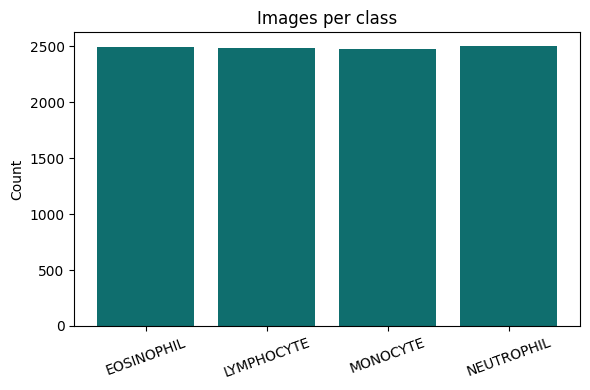

In [9]:
class_names = sorted(os.listdir(DATA_DIR))
print("Classes found:", class_names)

counts = {}
for c in class_names:
    folder = os.path.join(DATA_DIR, c)
    if os.path.isdir(folder):
        counts[c] = len(os.listdir(folder))

print("\nImage counts per class:")
for c, n in counts.items():
    print(f"  {c}: {n}")

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color="#0F6E6E")
plt.title("Images per class")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# NOTE: write down here whether classes are balanced or not —
# this observation goes straight into your validation framework doc later.

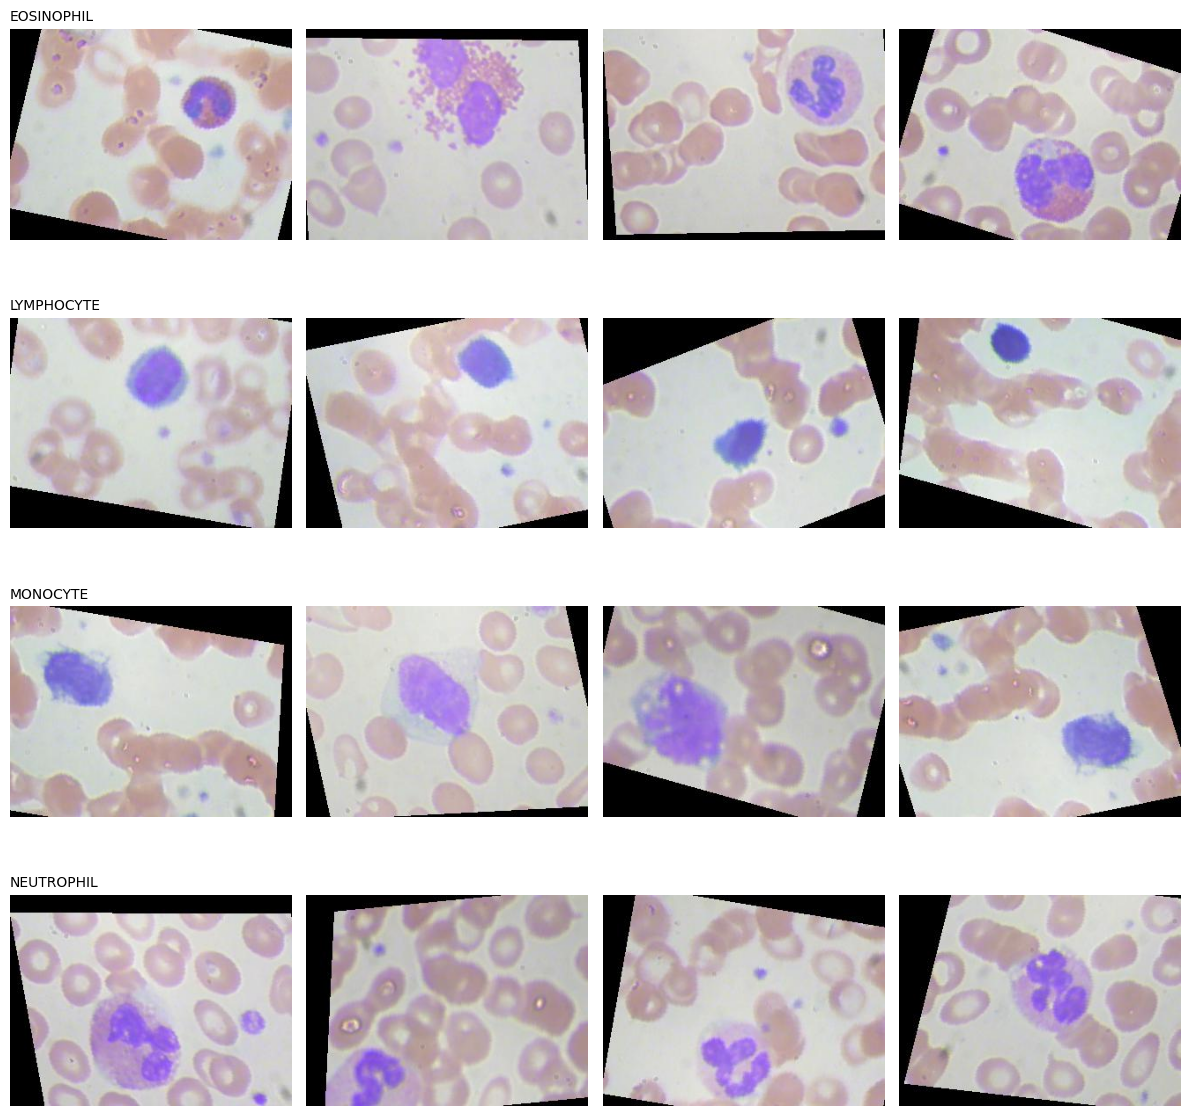

In [10]:
# Show a few sample images per class
fig, axes = plt.subplots(len(class_names), 4, figsize=(12, 3 * len(class_names)))
for i, c in enumerate(class_names):
    folder = os.path.join(DATA_DIR, c)
    files = os.listdir(folder)[:4]
    for j, f in enumerate(files):
        img = plt.imread(os.path.join(folder, f))
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(c)
    axes[i, 0].set_title(c, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

## Step 2 — Build train / validation datasets
Using `image_dataset_from_directory` with an 80/20 train/validation split from the TRAIN folder.
The separate TEST folder (provided by the dataset) is held out completely until final evaluation.

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Class order (matches label indices):", class_names)

# Preprocess for MobileNetV2 (scales pixel values appropriately) + prefetch for speed
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds_p = train_ds.map(preprocess).prefetch(AUTOTUNE)
val_ds_p = val_ds.map(preprocess).prefetch(AUTOTUNE)

Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Class order (matches label indices): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## Step 3 — Build the model (transfer learning)
MobileNetV2 pretrained on ImageNet, base frozen, small classification head on top.
This is the realistic approach for a small medical dataset — training a CNN from scratch
would need far more labeled data than we have here.

In [12]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze the pretrained base

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 4 — Train
With the base frozen, this trains fast even on CPU — usually a few minutes per epoch on this dataset size.

In [13]:
EPOCHS = 8

history = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=EPOCHS,
)

model.save("wbc_classifier.keras")
print("Model saved as wbc_classifier.keras")

Epoch 1/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.4851 - loss: 1.2092 - val_accuracy: 0.6484 - val_loss: 0.8855
Epoch 2/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6626 - loss: 0.8388 - val_accuracy: 0.7393 - val_loss: 0.7152
Epoch 3/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6967 - loss: 0.7402 - val_accuracy: 0.7629 - val_loss: 0.6419
Epoch 4/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7316 - loss: 0.6818 - val_accuracy: 0.7790 - val_loss: 0.6043
Epoch 5/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7538 - loss: 0.6418 - val_accuracy: 0.7926 - val_loss: 0.5622
Epoch 6/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.7519 - loss: 0.6218 - val_accuracy: 0.8001 - val_loss: 0.5426
Epoch 7/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7701 - loss: 0.5924 - val_accuracy: 0.8142 - val_loss: 0.5147
Epoch 8/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7661 - loss: 0.5985 - val_acc

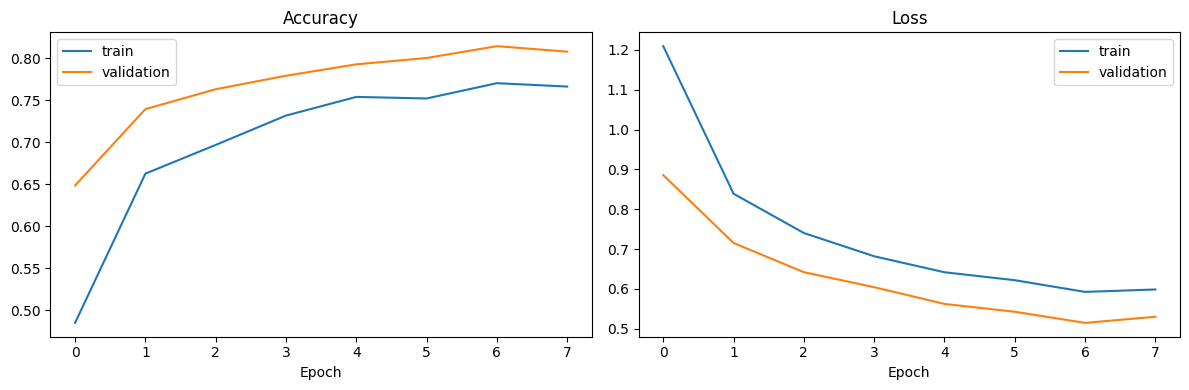

In [14]:
# Plot training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="validation")
ax[0].set_title("Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="validation")
ax[1].set_title("Loss")
ax[1].set_xlabel("Epoch")
ax[1].legend()
plt.tight_layout()
plt.show()

# NOTE: if validation accuracy plateaus much lower than training accuracy, that's overfitting —
# worth naming in your validation doc if it happens, along with what you'd try next (more augmentation,
# more data, stronger regularization).

## Step 5 — Evaluate on the held-out TEST set
This is the set the model has never seen at all, not even during validation.

In [15]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_class_names = test_ds.class_names
test_ds_p = test_ds.map(preprocess).prefetch(AUTOTUNE)

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds_p)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== Classification report (per-class precision/recall/F1) ===")
print(classification_report(y_true, y_pred, target_names=test_class_names))

Found 2487 files belonging to 4 classes.
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step
=== Classification report (per-class precision/recall/F1) ===
              precision    recall  f1-score   support

  EOSINOPHIL       0.52      0.37      0.43       623
  LYMPHOCYTE       0.70      0.45      0.55       620
    MONOCYTE       0.64      0.65      0.65       620
  NEUTROPHIL       0.47      0.78      0.59       624

    accuracy                           0.56      2487
   macro avg       0.59      0.56      0.55      2487
weighted avg       0.59      0.56      0.55      2487



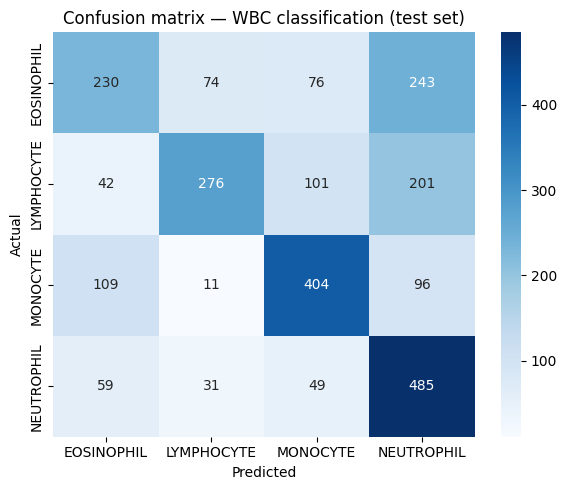

In [16]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Teal" if "Teal" in plt.colormaps() else "Blues",
            xticklabels=test_class_names, yticklabels=test_class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — WBC classification (test set)")
plt.tight_layout()
plt.show()

# NOTE: look at which cells get confused with which. Are any of these confusions
# clinically dangerous (e.g. would a real misclassification change a diagnosis)?
# This observation is critical for the risk analysis section of your validation doc.

## Step 6 — Look at specific misclassified examples
Numbers alone don't tell you *why* the model failed. Look at actual misclassified images.

Total misclassified: 1092 out of 2487


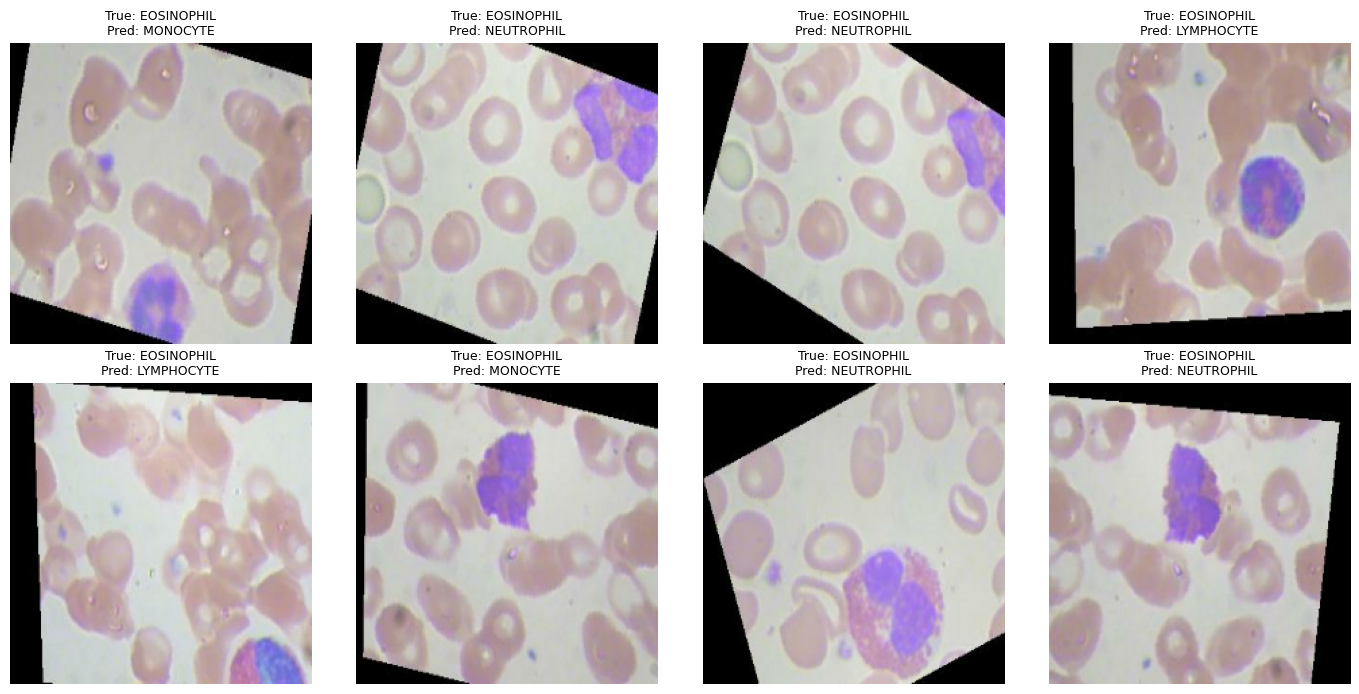

In [17]:
# Collect misclassified examples with their images
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")

# Grab the raw (un-preprocessed) images for display
all_images = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)

n_show = min(8, len(misclassified_idx))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, idx in enumerate(misclassified_idx[:n_show]):
    ax = axes[i // 4, i % 4]
    ax.imshow(all_images[idx].astype("uint8"))
    ax.set_title(f"True: {test_class_names[y_true[idx]]}\nPred: {test_class_names[y_pred[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 7 (stretch goal) — Grad-CAM: what is the model actually looking at?
This shows which part of the image most influenced the model's prediction — genuinely useful
for an explainability-conscious audience, and a strong thing to show in an interview.

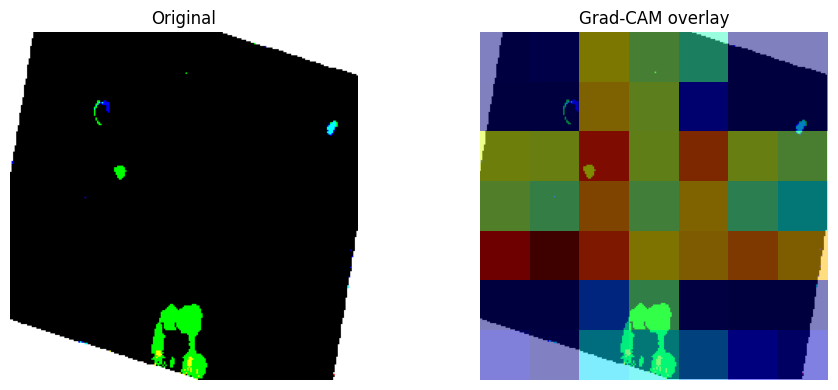

In [19]:
import matplotlib.cm as cm_module

# Simpler Grad-CAM using the base_model directly (Keras 3 compatible)
last_conv_layer = base_model.get_layer("Conv_1")

grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

sample_idx = misclassified_idx[0] if len(misclassified_idx) > 0 else 0
sample_img = all_images[sample_idx]
sample_input = preprocess_input(np.expand_dims(sample_img, axis=0))

with tf.GradientTape() as tape:
    conv_outputs, base_preds = grad_model(sample_input)
    # Use the full model's prediction to pick the class, then trace back through base_model's features
    full_preds = model(sample_input)
    pred_index = tf.argmax(full_preds[0])
    class_channel = base_preds[:, pred_index] if base_preds.shape[-1] == full_preds.shape[-1] else tf.reduce_sum(conv_outputs)

grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img.astype("uint8"))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(sample_img.astype("uint8"))
plt.imshow(heatmap.numpy(), cmap="jet", alpha=0.5, extent=(0, sample_img.shape[1], sample_img.shape[0], 0))
plt.title("Grad-CAM overlay")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 8 — Summary notes (fill these in, then transfer to VALIDATION_FRAMEWORK.md)

- Overall test accuracy: 56.1%
- Per-class precision/recall (copy from classification report above):  Eosinophil: Precision 52.3%, Recall 36.9%
  - Lymphocyte: Precision 70.4%, Recall 44.5%
  - Monocyte: Precision 64.1%, Recall 65.2%
  - Neutrophil: Precision 47.3%, Recall 77.7%

- Which classes get confused with which, and does it matter clinically:  Eosinophil↔Neutrophil is the biggest confusion (243 cases) — clinically expected, since
  both are granulocytes distinguished mainly by subtle granule color/texture. Monocyte↔Eosinophil
  confusion (109 cases) is more clinically surprising, since these cell types look structurally
  different — likely a model limitation (frozen ImageNet backbone) rather than genuine visual
  ambiguity. The model also shows a clear bias toward over-predicting Neutrophil overall
  (1,025 predictions vs. 624 true cases).

- Any signs of overfitting (train vs. validation gap): Based on the training curves, there are no obvious signs of overfitting. Both training and validation accuracy are increasing, and notably, the validation accuracy is often slightly higher or very close to the training accuracy. Similarly, the validation loss is consistently lower than the training loss. This pattern suggests the model might not be overfitting and could potentially benefit from more training epochs or a more complex architecture if higher performance is desired.

- What you'd do with more time/data:  Unfreeze the top few layers of the pretrained base and fine-tune at a low learning rate
  directly on the blood cell images, rather than only training the classification head.
  Would also try a backbone pretrained on histology/medical images instead of general photos,
  and validate across multiple labs/scanners/stain batches before trusting generalization.